
[INFO] Total de registros carregados: 120
[INFO] Experimentos processados: 3
[INFO] Horizontes: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']


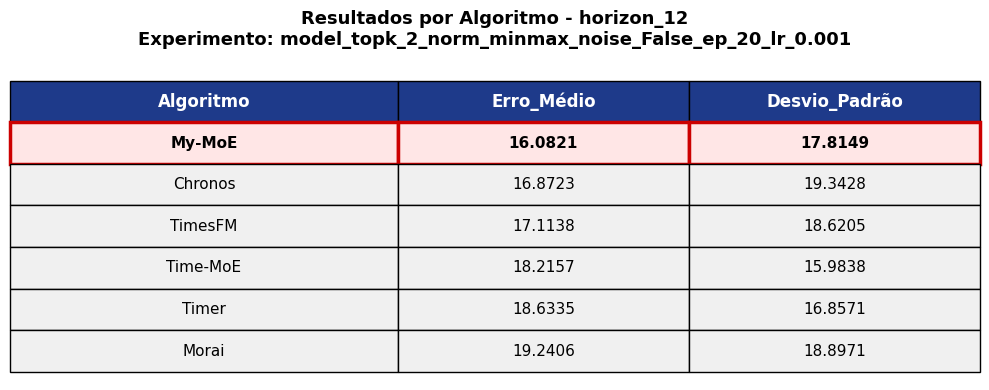

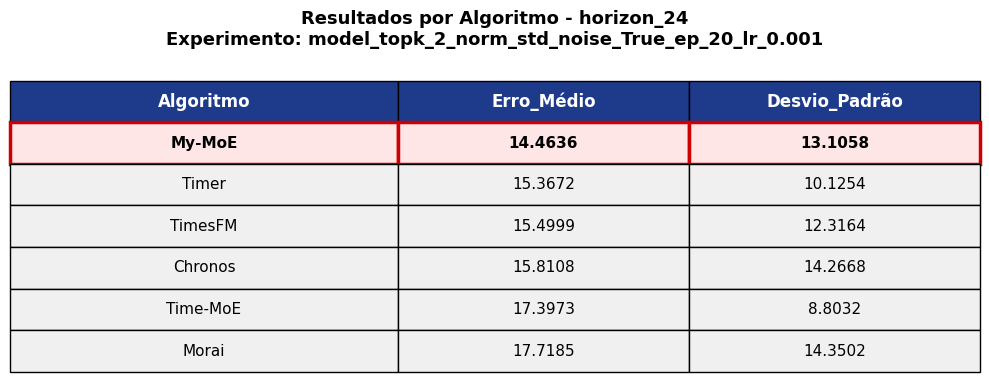

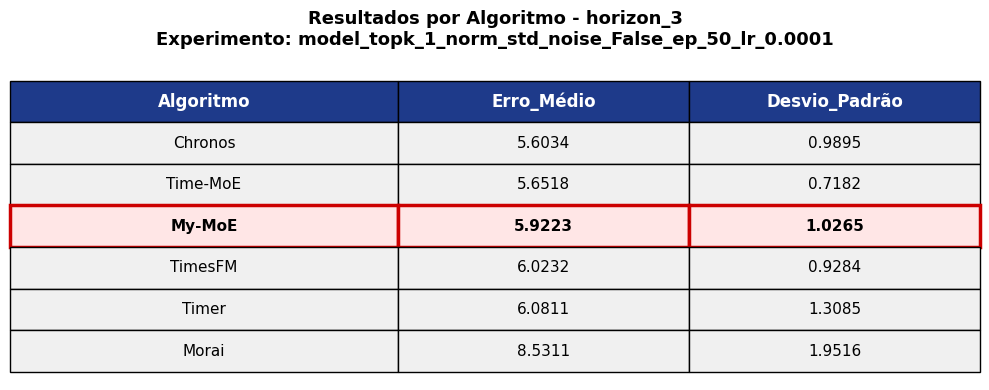

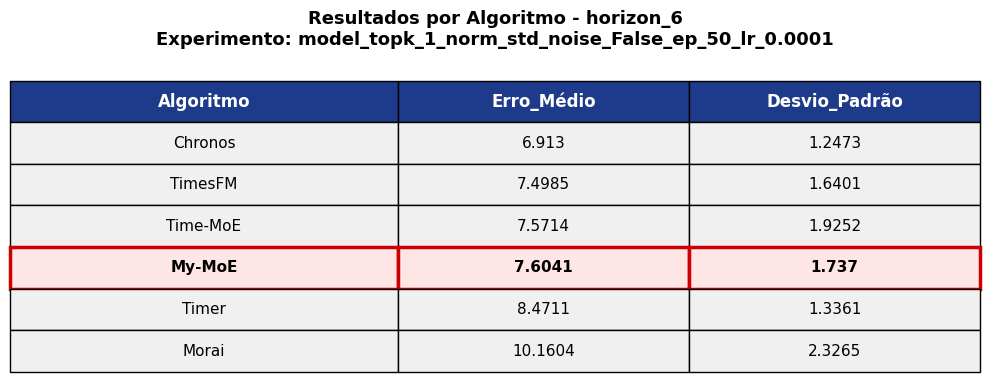


Tabelas geradas com sucesso!

Resumo:
- Total de registros: 120
- Algoritmos únicos: 6
- Horizontes: horizon_12, horizon_24, horizon_3, horizon_6


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_RESULTS_PATH = "ExperimentosSPNewRouter/results_by_state_year"

target_products = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

# Mapeamento dos melhores experimentos por horizonte
best_experiments = {
    # new router
    # "horizon_3": "model_topk_2_norm_std_noise_True_ep_50_lr_0.0001",
    # "horizon_6": "model_topk_2_norm_minmax_noise_True_ep_50_lr_0.001",
    # "horizon_12": "model_topk_2_norm_minmax_noise_False_ep_20_lr_0.001",
    # "horizon_24": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001"

    # normal 100 epochs
    "horizon_3": "model_topk_1_norm_std_noise_False_ep_50_lr_0.0001",
    "horizon_6": "model_topk_1_norm_std_noise_False_ep_50_lr_0.0001",
    "horizon_12": "model_topk_2_norm_minmax_noise_False_ep_20_lr_0.001",
    "horizon_24": "model_topk_2_norm_std_noise_True_ep_20_lr_0.001",

    # old
    # "horizon_3": "model_topk_2_norm_std_noise_True_ep_80_lr_0.0001",
    # "horizon_6": "model_topk_1_norm_std_noise_True_ep_80_lr_1e-05",
    # "horizon_12": "model_topk_1_norm_minmax_noise_True_ep_50_lr_1e-05",
    # "horizon_24": "model_topk_2_norm_std_noise_True_ep_50_lr_0.001",
}

rows_all = []

# Percorre apenas os melhores experimentos
for horizon, exp_name in best_experiments.items():
    exp_path = os.path.join(BASE_RESULTS_PATH, exp_name)
    
    if not os.path.isdir(exp_path):
        print(f"[AVISO] Experimento não encontrado: {exp_path}")
        continue
    
    # Percorre os horizontes dentro do experimento
    for horizon_folder in os.listdir(exp_path):
        horizon_path = os.path.join(exp_path, horizon_folder)
        
        if not os.path.isdir(horizon_path):
            continue
        
        # Verifica se é o horizonte correto
        if horizon_folder != horizon:
            continue
        
        # Percorre os CSVs (anos)
        for file in os.listdir(horizon_path):
            if not file.endswith(".csv"):
                continue

            year = os.path.splitext(file)[0]
            file_path = os.path.join(horizon_path, file)

            df = pd.read_csv(file_path)

            # Filtra apenas os produtos de interesse
            metric_cols = [c for c in target_products if c in df.columns]

            if len(metric_cols) == 0:
                print(f"[AVISO] Nenhuma coluna válida em {file_path}")
                continue

            df["erro_medio"] = df[metric_cols].mean(axis=1)

            for _, row in df.iterrows():
                rows_all.append({
                    "Algoritmo": row["Modelo"],
                    "Horizonte": horizon,
                    "Ano": year,
                    "Erro": row["erro_medio"],
                    "Experimento": exp_name
                })

# DataFrame único com tudo
df_all = pd.DataFrame(rows_all)

if len(df_all) == 0:
    print("\n[ERRO] Nenhum dado foi carregado! Verifique os caminhos dos experimentos.")
else:
    print(f"\n[INFO] Total de registros carregados: {len(df_all)}")
    print(f"[INFO] Experimentos processados: {df_all['Experimento'].nunique()}")
    print(f"[INFO] Horizontes: {sorted(df_all['Horizonte'].unique())}")

    # ==============================
    # TABELA: ALGORITMO / HORIZONTE
    # ==============================

    df_tabela = (
        df_all
        .groupby(["Algoritmo", "Horizonte"])
        .agg(
            Erro_Médio=("Erro", "mean"),
            Desvio_Padrão=("Erro", "std")
        )
        .reset_index()
    )

    # Ordena por Horizonte e Erro Médio
    df_tabela = df_tabela.sort_values(["Horizonte", "Erro_Médio"])

    # Formata os valores
    df_tabela["Erro_Médio"] = df_tabela["Erro_Médio"].round(4)
    df_tabela["Desvio_Padrão"] = df_tabela["Desvio_Padrão"].round(4)

    # ==============================
    # VISUALIZAÇÃO DA TABELA
    # ==============================

    # Lista de horizontes únicos
    horizontes = sorted(df_tabela["Horizonte"].unique())

    # Cria uma tabela visual para cada horizonte
    for horizonte in horizontes:
        df_h = df_tabela[df_tabela["Horizonte"] == horizonte].copy()
        df_h = df_h.sort_values("Erro_Médio")
        
        # Remove coluna Horizonte para tabela visual
        df_display = df_h[["Algoritmo", "Erro_Médio", "Desvio_Padrão"]].reset_index(drop=True)
        
        # Cria figura para tabela
        fig, ax = plt.subplots(figsize=(10, len(df_display) * 0.5 + 1))
        ax.axis('tight')
        ax.axis('off')
        
        # Cores de fundo para linhas (destaque My-MoE)
        colors = []
        for algoritmo in df_display["Algoritmo"]:
            if algoritmo == "My-MoE":
                colors.append(['#FFE6E6', '#FFE6E6', '#FFE6E6'])  # Vermelho claro
            else:
                colors.append(['#F0F0F0', '#F0F0F0', '#F0F0F0'])  # Cinza claro
        
        # Cria tabela
        table = ax.table(cellText=df_display.values,
                         colLabels=df_display.columns,
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.4, 0.3, 0.3],
                         cellColours=colors)
        
        # Estiliza tabela
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2.5)
        
        # Estiliza cabeçalho (azul escuro)
        for i in range(len(df_display.columns)):
            cell = table[(0, i)]
            cell.set_facecolor('#1E3A8A')  # Azul escuro
            cell.set_text_props(weight='bold', color='white', fontsize=12)
        
        # Destaca linhas My-MoE com borda
        for i, algoritmo in enumerate(df_display["Algoritmo"], start=1):
            if algoritmo == "My-MoE":
                for j in range(len(df_display.columns)):
                    cell = table[(i, j)]
                    cell.set_edgecolor('#CC0000')
                    cell.set_linewidth(2.5)
                    cell.set_text_props(weight='bold')
        
        # Mostra experimento usado
        exp_usado = best_experiments[horizonte]
        plt.title(f"Resultados por Algoritmo - {horizonte}\nExperimento: {exp_usado}", 
                  fontsize=13, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

    print("\nTabelas geradas com sucesso!")
    print(f"\nResumo:")
    print(f"- Total de registros: {len(df_all)}")
    print(f"- Algoritmos únicos: {df_all['Algoritmo'].nunique()}")
    print(f"- Horizontes: {', '.join(horizontes)}")